# Noise results

Analyze BasicPitch, CREPE, and Librosa under different noise types and SNRs, merged with `manifest_noise.csv`. Generate summary tables and dot plots with mean bars, saving outputs to `Noise_Results`.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.3f}".format

out_dir = Path("Noise_Results")
out_dir.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 150


In [18]:
manifest = pd.read_csv("manifest_noise.csv")

noise_files = [
    ("basic_pitch", "5dB", "basic_pitch_noise_5db.csv"),
    ("basic_pitch", "15dB", "basic_pitch_noise_15db.csv"),
    ("crepe", "5dB", "crepe_noise_5db.csv"),
    ("crepe", "15dB", "crepe_noise_15db.csv"),
    ("librosa", "5dB", "librosa_noise_5db.csv"),
    ("librosa", "15dB", "librosa_noise_15db.csv"),
]

frames = []
for model, snr, path in noise_files:
    df = pd.read_csv(path)
    df = df[df["filename"].isin(manifest["track_id"])].copy()
    df = df.merge(manifest, left_on="filename", right_on="track_id", how="left")
    df["model"] = model
    df["snr"] = snr
    frames.append(df)

metrics = pd.concat(frames, ignore_index=True)
metrics = metrics[["filename", "model", "snr", "class_tag", "noise_tag", "OA", "RPA", "RCA", "VR"]]

# Clean baselines per model for loss computation
clean_files = {
    "basic_pitch": "basic_pitch_clean.csv",
    "crepe": "crepe_clean.csv",
    "librosa": "librosa_clean.csv",
}
clean_means = []
for model, path in clean_files.items():
    df = pd.read_csv(path)
    df = df[df["filename"].isin(manifest["track_id"])].copy()
    clean_means.append(
        df[["OA", "RPA", "RCA", "VR"]].mean().to_frame().T.assign(model=model)
    )
clean_means = pd.concat(clean_means, ignore_index=True).set_index("model")

metrics.head()


,filename,model,snr,class_tag,noise_tag,OA,RPA,RCA,VR
0,CelestialShore_DieForUs_STEM_02,basic_pitch,5dB,vocal,people,0.773,0.897,0.886,0.786
1,MusicDelta_GriegTrolltog_STEM_07,basic_pitch,5dB,instrument,street,0.754,0.481,0.481,0.764
2,AimeeNorwich_Child_STEM_04,basic_pitch,5dB,vocal,people,0.802,0.927,0.919,0.813
3,SecretMountains_HighHorse_STEM_09,basic_pitch,5dB,vocal,street,0.808,0.831,0.808,0.844
4,CelestialShore_DieForUs_STEM_01,basic_pitch,5dB,vocal,street,0.819,0.904,0.880,0.829


## Summary tables
- Overall mean metrics per model (best per metric highlighted)
- Means by SNR level (5dB/15dB)
- Means by noise type (room/street/people)
- Means by source type (instrument/vocal)
- Loss vs clean (overall and by SNR; delta overall best/worst highlighted)

In [19]:
overall_table = (
    metrics.groupby("model")[["OA", "RPA", "RCA", "VR"]]
    .mean()
    .sort_values("OA", ascending=False)
)

snr_table = metrics.groupby(["model", "snr"])[["OA", "RPA", "RCA", "VR"]].mean()
noise_table = metrics.groupby(["model", "noise_tag"])[["OA", "RPA", "RCA", "VR"]].mean()
class_table = metrics.groupby(["model", "class_tag"])[["OA", "RPA", "RCA", "VR"]].mean()

# Loss vs clean (noise minus clean baseline)
delta_overall = overall_table.subtract(clean_means, axis=0)
delta_snr_table = snr_table.subtract(clean_means, level=0)

highlighted_overall = overall_table.style.highlight_max(axis=0, color="#ffe08a")
highlighted_delta_overall = delta_overall.style.highlight_max(axis=0, color="#b3ffb3")                                            .highlight_min(axis=0, color="#ffcccc")

overall_table.to_csv(out_dir / "overall_table.csv")
snr_table.to_csv(out_dir / "snr_table.csv")
noise_table.to_csv(out_dir / "noise_table.csv")
class_table.to_csv(out_dir / "class_table.csv")
delta_overall.to_csv(out_dir / "delta_overall_table.csv")
delta_snr_table.to_csv(out_dir / "delta_snr_table.csv")
highlighted_overall.to_html(out_dir / "overall_table_highlight.html")
highlighted_delta_overall.to_html(out_dir / "delta_overall_table_highlight.html")

display(highlighted_overall)
display(snr_table)
display(noise_table)
display(class_table)
display(highlighted_delta_overall)
display(delta_snr_table)


,OA,RPA,RCA,VR
model,,,,
basic_pitch,0.761376,0.745038,0.719802,0.811070
librosa,0.659217,0.772567,0.701554,0.720632
crepe,0.455739,0.930713,0.827582,0.494123


OA   RPA   RCA    VR
model       snr                         
basic_pitch 15dB 0.765 0.759 0.732 0.824
            5dB  0.760 0.739 0.715 0.806
crepe       15dB 0.466 0.971 0.917 0.480
            5dB  0.452 0.914 0.791 0.500
librosa     15dB 0.693 0.846 0.780 0.754
            5dB  0.645 0.742 0.670 0.707

OA   RPA   RCA    VR
model       noise_tag                        
basic_pitch people    0.757 0.761 0.733 0.813
            room      0.745 0.724 0.708 0.793
            street    0.781 0.744 0.715 0.825
crepe       people    0.469 0.931 0.817 0.510
            room      0.450 0.917 0.810 0.496
            street    0.444 0.943 0.856 0.474
librosa     people    0.685 0.780 0.716 0.760
            room      0.555 0.747 0.659 0.616
            street    0.722 0.787 0.723 0.767

OA   RPA   RCA    VR
model       class_tag                         
basic_pitch instrument 0.771 0.793 0.775 0.817
            vocal      0.755 0.713 0.683 0.807
crepe       instrument 0.520 0.891 0.726 0.585
            vocal      0.413 0.957 0.895 0.433
librosa     instrument 0.646 0.698 0.627 0.719
            vocal      0.668 0.822 0.751 0.722

,OA,RPA,RCA,VR
model,,,,
basic_pitch,0.039727,-0.047282,-0.052644,0.013238
crepe,-0.061728,-0.029961,-0.091698,-0.046201
librosa,0.000281,-0.078585,-0.095034,-0.002726


OA    RPA    RCA     VR
model       snr                             
basic_pitch 15dB  0.043 -0.033 -0.040  0.026
            5dB   0.038 -0.053 -0.058  0.008
crepe       15dB -0.052  0.010 -0.002 -0.060
            5dB  -0.066 -0.046 -0.128 -0.041
librosa     15dB  0.034 -0.005 -0.017  0.031
            5dB  -0.014 -0.109 -0.127 -0.016

## Plots (saved individually)
- Metrics dot plot with mean bars (all metrics)
- OA vs SNR (5dB vs 15dB)
- OA by noise type
- OA by source type
- OA by noise type × source type

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.26966710777846514, 0.4568837962313781, 0.39739568702782224)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

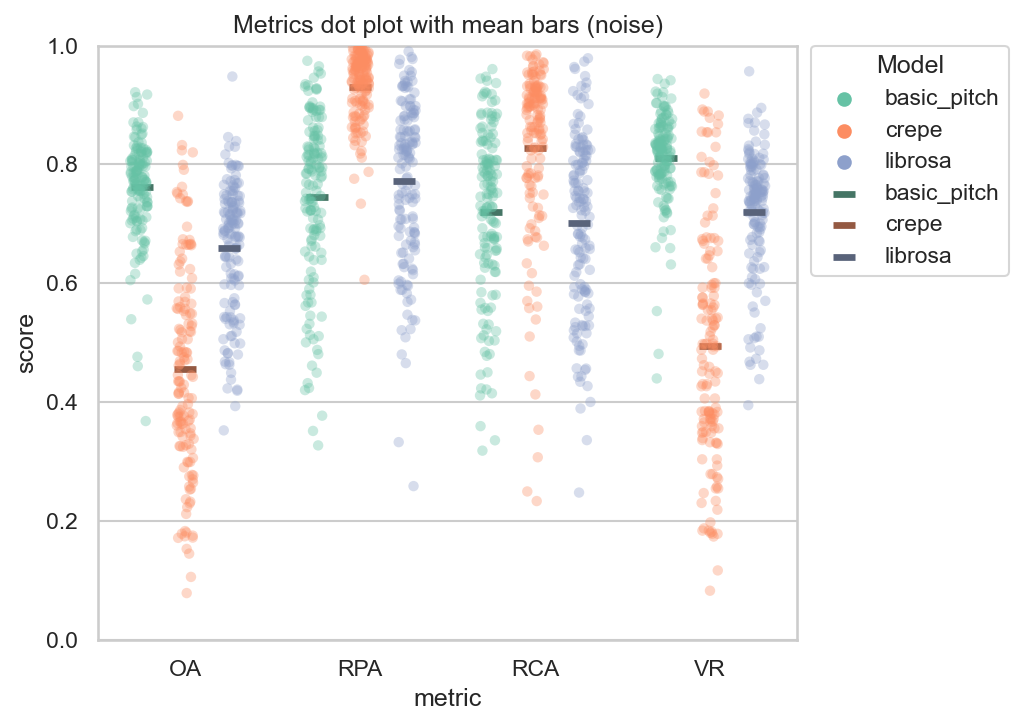

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.26966710777846514, 0.4568837962313781, 0.39739568702782224)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

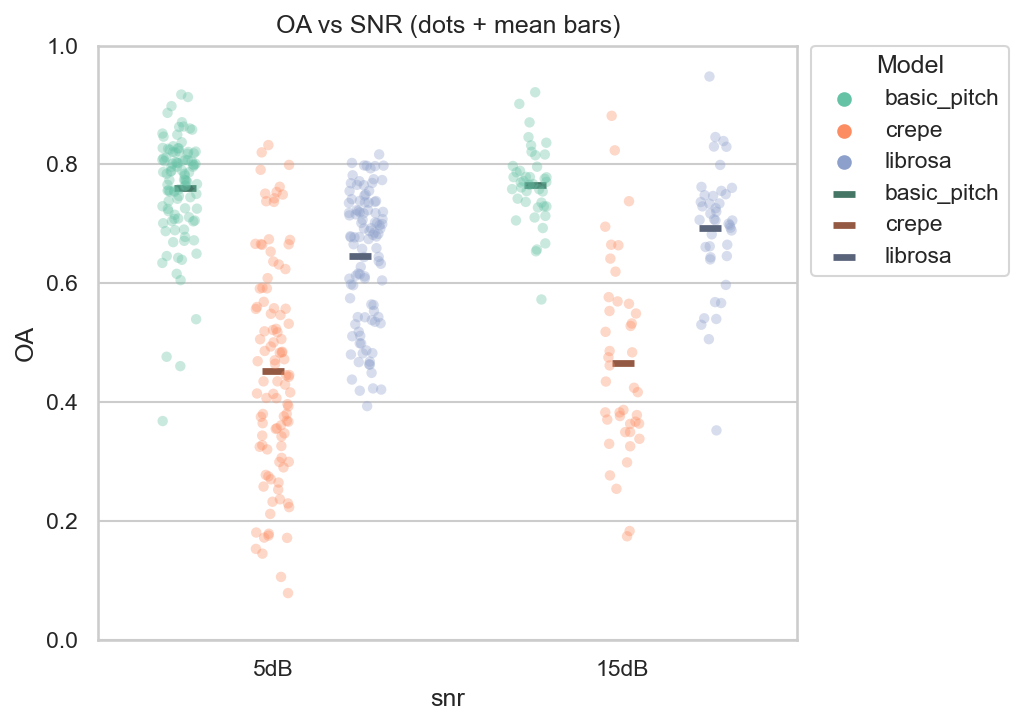

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.26966710777846514, 0.4568837962313781, 0.39739568702782224)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

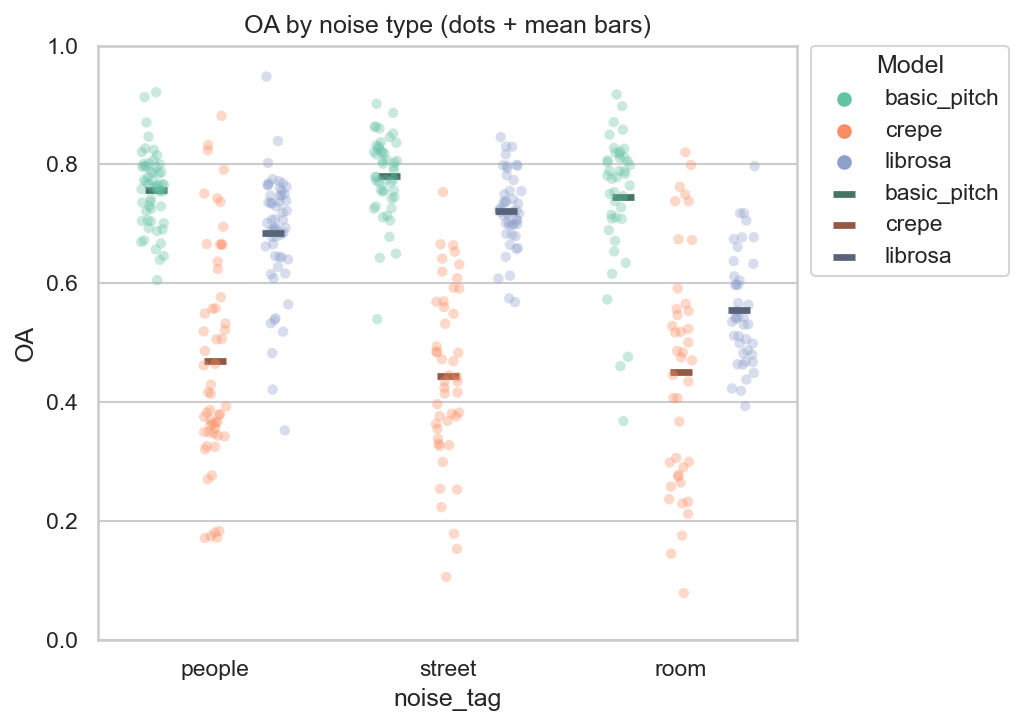

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.26966710777846514, 0.4568837962313781, 0.39739568702782224)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

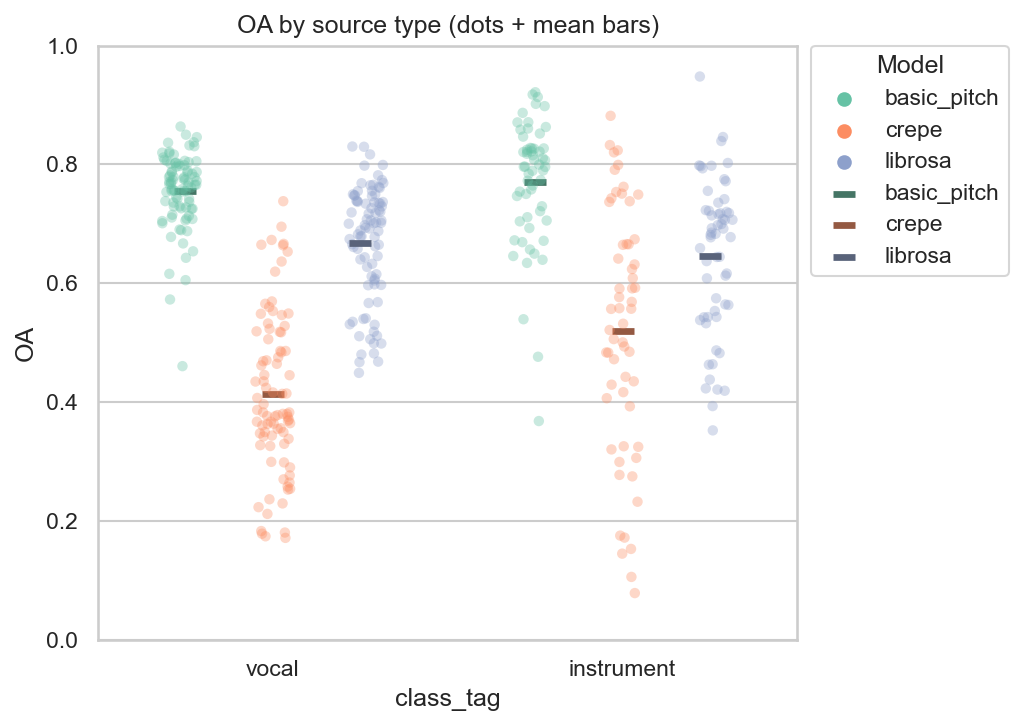

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.5432199095466269, 0.11796843348973814, 0.12194923109679687)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

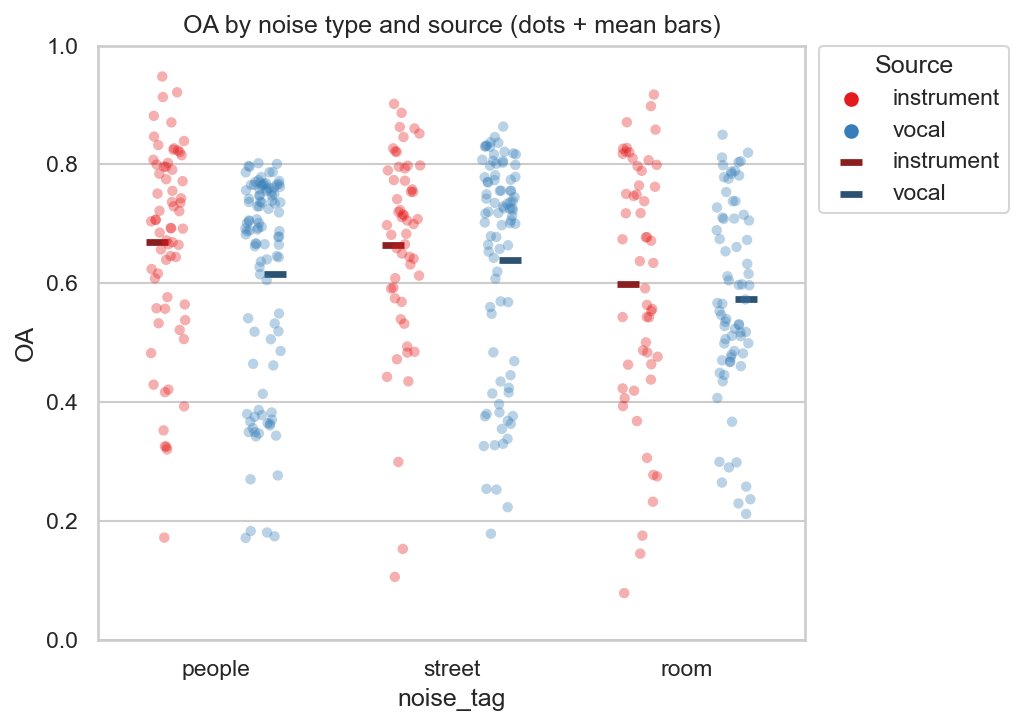

In [20]:
long_metrics = metrics.melt(
    id_vars=["filename", "model", "snr", "class_tag", "noise_tag"],
    value_vars=["OA", "RPA", "RCA", "VR"],
    var_name="metric",
    value_name="score",
)

hue_order = sorted(metrics["model"].unique())
palette = sns.color_palette("Set2", n_colors=len(hue_order))
mean_palette = [sns.dark_palette(c, 3)[1] for c in palette]
color_map = dict(zip(hue_order, palette))
mean_map = dict(zip(hue_order, mean_palette))

class_order = sorted(metrics["class_tag"].unique())
class_palette = sns.color_palette("Set1", n_colors=len(class_order))
class_mean_palette = [sns.dark_palette(c, 3)[1] for c in class_palette]
class_mean_map = dict(zip(class_order, class_mean_palette))

# Plot 1: per-metric dots + mean bars
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=long_metrics,
    x="metric",
    y="score",
    hue="model",
    hue_order=hue_order,
    palette=color_map,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=long_metrics,
    x="metric",
    y="score",
    hue="model",
    hue_order=hue_order,
    palette=[mean_map[h] for h in hue_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("Metrics dot plot with mean bars (noise)")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "metrics_dot_mean.png", bbox_inches="tight")
plt.show()

# Plot 2: OA vs SNR
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=metrics,
    x="snr",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=color_map,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=metrics,
    x="snr",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=[mean_map[h] for h in hue_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("OA vs SNR (dots + mean bars)")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "oa_snr_dot_mean.png", bbox_inches="tight")
plt.show()

# Plot 3: OA by noise type
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=metrics,
    x="noise_tag",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=color_map,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=metrics,
    x="noise_tag",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=[mean_map[h] for h in hue_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("OA by noise type (dots + mean bars)")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "oa_noise_dot_mean.png", bbox_inches="tight")
plt.show()

# Plot 4: OA by source type
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=metrics,
    x="class_tag",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=color_map,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=metrics,
    x="class_tag",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=[mean_map[h] for h in hue_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("OA by source type (dots + mean bars)")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "oa_source_dot_mean.png", bbox_inches="tight")
plt.show()

# Plot 5: OA by noise type × source type
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=metrics,
    x="noise_tag",
    y="OA",
    hue="class_tag",
    hue_order=class_order,
    palette=class_palette,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=metrics,
    x="noise_tag",
    y="OA",
    hue="class_tag",
    hue_order=class_order,
    palette=[class_mean_map[h] for h in class_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("OA by noise type and source (dots + mean bars)")
ax.set_ylim(0, 1)
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "oa_noise_source_dot_mean.png", bbox_inches="tight")
plt.show()
